In [1]:
import simpeg.electromagnetics.time_domain as tdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
from discretize import TensorMesh
import empymod as empy

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
mpl.rcParams.update({"font.size":14, "font.family":"Times New Roman"})

In [95]:
i_start = 3
times = (np.array([
    104.9, 132.7, 160.5, 188.3, 229.9,
    285.5, 341, 396.6, 452.2, 507.7,
    563.3, 618.8, 688.3, 771.6, 854.9,
    938.3, 1021.6, 1118.8, 1229.9, 1341.0,
    1466.0, 1604.9, 1743.8, 1896.6, 2063.3,
    2229.9, 2410.5, 2604.9, 2813.3, 3035.5
    ]) * 1e-6)[i_start:]

In [5]:
area:str = "NE"
path:str = f"/Users/sgkang09/Dropbox/ags_data/DIG_2017_0001/Flightline_data/Geosoft_databases/11-024_Alberta_{area}.csv"
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight"]\
    + [f"zoff30[{i}]" for i in range(30)]

In [6]:
# Load data
dobs_total = pd.read_csv(path)[picker]

In [7]:
dobs_total.head()

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,zoff30[0],zoff30[1],zoff30[2],zoff30[3],...,zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24],zoff30[25],zoff30[26],zoff30[27],zoff30[28],zoff30[29]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,4554.725041,3266.915041,2627.075041,2210.225041,...,101.325041,81.035041,64.625041,50.545041,40.495041,28.595041,20.135041,17.725041,11.095041,4.355041
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,4545.241420,3259.371420,2621.841420,2206.031420,...,101.021420,80.681420,64.331420,50.241420,40.191420,28.141420,19.751420,17.621420,10.931420,4.231420
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,4536.177913,3251.867913,2616.617913,2201.817913,...,100.717913,80.387913,64.067913,49.897913,39.827913,27.707913,19.367913,17.547913,10.687913,4.137913
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,4528.109667,3244.549667,2611.509667,2197.669667,...,100.479667,80.169667,63.829667,49.569667,39.469667,27.359667,19.069667,17.509667,10.379667,4.069667
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,4521.036778,3237.416778,2606.496778,2193.566778,...,100.266778,80.016778,63.626778,49.266778,39.096778,27.046778,18.826778,17.456778,10.066778,4.016778


In [120]:
index = 1000
altitude = dobs_total.iloc[index,1]
currents = dobs_total.iloc[index,2]
radius = 10
area = np.pi * radius**2
dobs = -(dobs_total.iloc[index,6:]*1e-9)[i_start:]

## Defining the Survey

In [121]:
# Source loop geometry
source_location = np.array([0.0, 0.0, altitude])  # (3, ) numpy.array_like
source_orientation = "z"  # "x", "y" or "z"
source_current = currents# maximum on-time current (A)
source_radius = 5.0  # source loop radius (m)
N:int = 5 # Number of turns in the transmitter loop

# Receiver geometry
receiver_location = np.array([0.0, 0.0, altitude])  # or (N, 3) numpy.ndarray
receiver_orientation = "z"  # "x", "y" or "z"

# Receiver list
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_location, times, orientation=receiver_orientation
    )
)

In [122]:
times

array([0.0001883, 0.0002299, 0.0002855, 0.000341 , 0.0003966, 0.0004522,
       0.0005077, 0.0005633, 0.0006188, 0.0006883, 0.0007716, 0.0008549,
       0.0009383, 0.0010216, 0.0011188, 0.0012299, 0.001341 , 0.001466 ,
       0.0016049, 0.0017438, 0.0018966, 0.0020633, 0.0022299, 0.0024105,
       0.0026049, 0.0028133, 0.0030355])

In [123]:
# Define the source waveform. (unit step-off, rectangular, triangular, quarter-sine, custom)
# Triangular waveform. 
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(
    start_time,
    off_time,
    peak_time
)

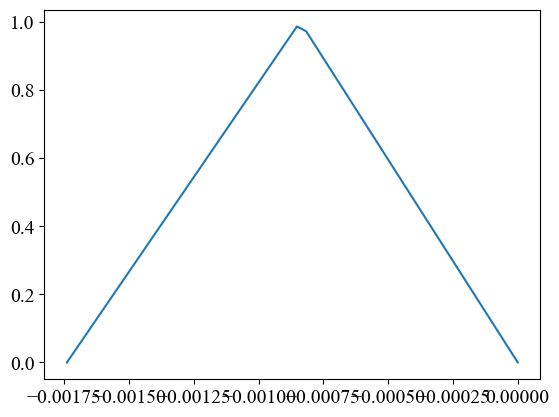

In [124]:
time_tmp = np.linspace(-1.74e-3, 0)
values = [waveform.eval(t) for t in time_tmp]

plt.plot(time_tmp, values)

In [125]:
# Sources
source_list = [
    tdem.sources.CircularLoop(
        receiver_list=receiver_list,
        location=source_location,
        orientation=source_orientation,
        waveform=waveform,
        current=source_current,
        radius=source_radius,
        # n_turns=N,
    )
]

# Survey
survey = tdem.Survey(source_list)

In [156]:
# 5nT noise level
# tmp = 5.0*1e-9 / np.max(np.abs(dobs))
tmp = 0.05
print(tmp)
uncertainties = tmp * np.abs(dobs) * np.ones(np.shape(dobs)) + 1e-9 * 5


0.05


In [157]:
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

In [158]:
# estimated host conductivity (S/m)
estimated_conductivity = 1e-2
# minimum diffusion distance
d_min = 1250 * np.sqrt(times.min() / estimated_conductivity)
print("MINIMUM DIFFUSION DISTANCE: {} m".format(d_min))
# maximum diffusion distance
d_max = 1250 * np.sqrt(times.max() / estimated_conductivity)
print("MAXIMUM DIFFUSION DISTANCE: {} m".format(d_max))

MINIMUM DIFFUSION DISTANCE: 171.5280589291443 m
MAXIMUM DIFFUSION DISTANCE: 688.6921482055681 m


In [159]:
depth_min = 5  # top layer thickness
depth_max = 100.0  # depth to lowest layer
geometric_factor = 1.15  # rate of thickness increase

In [160]:
# Increase subsequent layer thicknesses by the geometric factors until
# it reaches the maximum layer depth.
layer_thicknesses = [depth_min]
while np.sum(layer_thicknesses) < depth_max:
    layer_thicknesses.append(geometric_factor * layer_thicknesses[-1])

n_layers = len(layer_thicknesses) + 1  # Number of layers

In [161]:
# m = log(conductivity)  
# log_conductivity_map = maps.ExpMap(nP=n_layers) # nP is the number of layers

l_bound = 1e-5
u_bound = 10

log_conductivity_map = maps.LogisticSigmoidMap(nP=n_layers, lower_bound=l_bound, upper_bound=u_bound) # nP is the number of layers

In [162]:
# Starting model is log-conductivity values (S/m)
starting_cond = 5e-2
# starting_conductivity_model = np.log(7e-2 * np.ones(n_layers))
starting_conductivity_model = np.log((starting_cond -l_bound)/(u_bound - starting_cond) * np.ones(n_layers))
# Reference model is also log-resistivity values (S/m)
reference_conductivity_model = starting_conductivity_model.copy()
# reference_conductivity_model = np.log(1e-2 * np.ones(n_layers))

In [163]:
simulation_L2 = tdem.Simulation1DLayered(
    survey=survey, thicknesses=layer_thicknesses, sigmaMap=log_conductivity_map
)

In [180]:
simulation_L2.sigma

array([0.44448072, 0.34457153, 0.29711268, 0.30269331, 0.29678944,
       0.21051408, 0.10832021, 0.057198  , 0.03582716, 0.02578883,
       0.02053447])

In [164]:
dpred_data = simulation_L2.dpred(starting_conductivity_model)

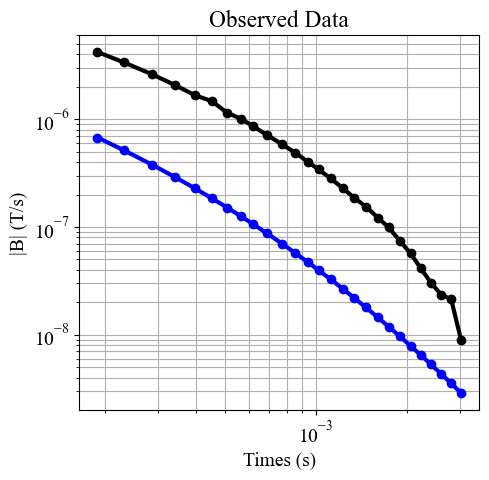

In [165]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax.loglog(times, np.abs(dobs), "k-o", lw=3)
ax.loglog(times, np.abs(dpred_data), "b-o", lw=3)
ax.grid(which="both")
ax.set_xlabel("Times (s)")
ax.set_ylabel("|B| (T/s)")
ax.set_title("Observed Data")
plt.show()

In [166]:
dmis_L2 = data_misfit.L2DataMisfit(simulation=simulation_L2, data=data_object)

In [167]:
# Define 1D cell widths
h = np.r_[layer_thicknesses, layer_thicknesses[-1]]
h = np.flipud(h)

# Create regularization mesh
regularization_mesh = TensorMesh([h], "N")
print(regularization_mesh)


  TensorMesh: 11 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     11       -119.11         -0.00      5.00     17.59    1.15




In [181]:
reg_L2 = regularization.WeightedLeastSquares(
    regularization_mesh,
    alpha_s=1e-10,
    # alpha_x=0.0, # weighting for the first derivative term
    length_scale_x=10.0,
    reference_model=reference_conductivity_model,# Log resistivity
    reference_model_in_smooth=False,
)

In [182]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=10, maxIterLS=20, cg_maxiter=50, cg_rtol=1e-3
)

$$
\phi(m)=\phi_{d}(m)+\beta\cdot\phi_m(m)
$$

**Trade-off Parameter:** $\beta_0 = \text{beta0\_ratio} \cdot \frac{\lambda_{max}(J^T W_d^T W_d J)}{\lambda_{max}(W_m^T W_m)}$

In [183]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

In [184]:
# Inversion Directives

update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
# Initial beta
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1)
# Beta schedule: Decrease beta by a factor of 2 every 3 iterations
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [starting_beta, beta_schedule, target_misfit]

In [185]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_model_L2 = inv_L2.run(starting_conductivity_model)

# Output Table Columns:
# #:Iteration number
# beta: Trade-off parameter (weighting of the regularization)
# phi_d: Data misfit
# phi_m: Model misfit
# f: Total objective function value (phi_d + beta * phi_m)
# |proj(x-g)-x|: Gradient projection (convergence indicator)
# LS: Line search iterations 

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 27.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.05e-02  4.33e+03  0.00e+00  4.33e+03                                 
   1  1.05e-02  9.74e+02  5.40e+01  9.74e+02    4.95e+02      1              
   2  5.23e-03  8.32e+02  1.98e+02  8.33e+02    1.60e+03      0              
   3  2.62e-03  3.52e+02  5.32e+02  3.54e+02    1.62e+03      0              
   4  1.31e-03  1.03e+02  9.40e+02  1.04e+02    7.07e+02      0              
   5  6.54e-04  2.64e+01  1.37e+03  2.73e+01    8.65e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 7.5952e+01 <= tolF*(1+|f0|) = 4.3261e+02
0 : |xc-x_last| = 2.2648e+00 <= tolX*(1+|x0|) = 1.8557e+00
0 : |proj(x-g)-x|    = 8.6523e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|   

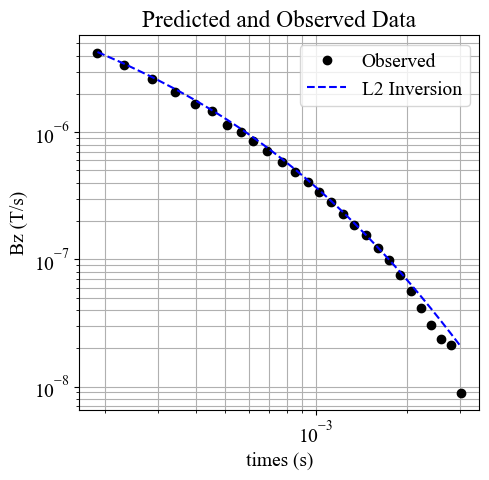

In [186]:
dpred_L2 = simulation_L2.dpred(recovered_model_L2)

fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax1.loglog(times, np.abs(dobs), "ko")
ax1.loglog(times, np.abs(dpred_L2), "b--")
ax1.grid(which="both")
ax1.set_xlabel("times (s)")
ax1.set_ylabel("Bz (T/s)")
ax1.set_title("Predicted and Observed Data")
ax1.legend(["Observed", "L2 Inversion"], loc="upper right")
plt.show()

In [193]:
recovered_conductivities = log_conductivity_map * recovered_model_L2

In [194]:
def inverse_map(x):
    return (u_bound - l_bound) / (1 + np.exp(-x)) + l_bound

In [195]:
# recovered_conductivities = inverse_map(recovered_conductivities)

In [196]:
recovered_conductivities

array([0.4881181 , 0.42187577, 0.25092039, 0.21802909, 0.30785219,
       0.30012668, 0.11765157, 0.0349195 , 0.01360238, 0.00699066,
       0.00445031])

In [191]:
final_misfit = dmis_L2(recovered_model_L2)
chi_squared = final_misfit / times.size
print(f"{chi_squared=:.2f}")

chi_squared=0.98


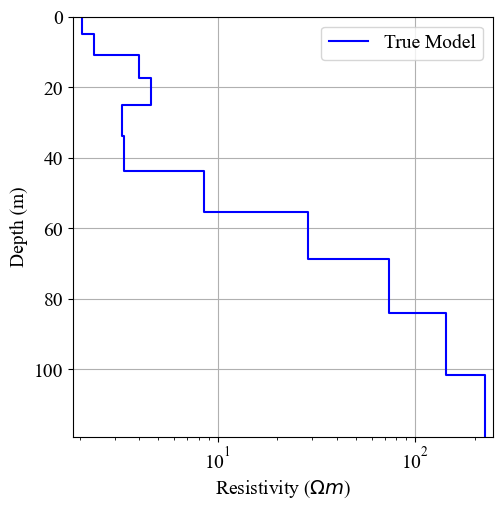

In [197]:
# Plot true model and recovered model
fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_axes([0.2, 0.15, 0.7, 0.7])
plot_1d_layer_model(
    layer_thicknesses, 1/recovered_conductivities, ax=ax1, color="b"
)
ax1.grid()
ax1.set_xlabel(r"Resistivity ($\Omega m$)")
ax1.legend(["True Model", "L2-Model"])
plt.show()